# Residual FY0 Test daily densification exploration

This standalone notebook reads the completed static FY0 artifacts and explores daily persistence of `residual_signed_raw__fh0` for Layers 3, 6, 9, 11, and 12. It does not refit Ridge and does not write source-code or YAML files.

The 2025 test period has already been opened. Every method comparison in this notebook is exploratory and must not be presented as a closed confirmatory test. Tradable variants activate on the next trading session; `event_same_day_reference` exists only to reproduce the earlier event-day result.

In [1]:
import hashlib
import json
import os
import shutil
import sys
import tempfile
import time
from datetime import datetime
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display
from scipy.stats import spearmanr

_base = Path('/home/intern_fjq_2026').resolve()
_current = Path.cwd().resolve()
_candidates = [
    _base / 'Projects' / 'chinese-wwm-roberta',
    _base.parent / 'intern_fjq_2026' / 'Projects' / 'chinese-wwm-roberta',
    _current,
    _current.parent,
]
ROOT = next((path for path in _candidates if (path / 'src').is_dir()), None)
assert ROOT is not None, 'Repository root was not found'
os.chdir(ROOT)
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

from src.config import load_yaml_config

def resolve_path(value):
    path = Path(str(value)).expanduser()
    return path.resolve() if path.is_absolute() else (ROOT / path).resolve()

In [2]:
CONFIG_PATH = resolve_path(os.environ.get(
    'LAYER_PROBE_STATIC_CONFIG',
    ROOT / 'configs' / 'layer_probe_static_fy0_csi300.yaml',
))
config = load_yaml_config(CONFIG_PATH)
RUN_DIR = resolve_path(config['output']['run_directory'])
EVALUATION_DIR = RUN_DIR / 'csi300_rank_ic'
SOURCE_FACTOR_PATH = EVALUATION_DIR / 'stock_day_factors.parquet'
REFERENCE_RANK_IC_PATH = EVALUATION_DIR / 'rank_ic_summary.csv'
SOURCE_MANIFEST_PATH = EVALUATION_DIR / 'manifest.json'
RETURN_PATH = resolve_path(config['direct_return']['industry_adjusted_daily_path'])
WEIGHTS_PATH = resolve_path(config['csi300_evaluation']['weights_path'])
OUTPUT_RUN_ID = os.environ.get(
    'LAYER_PROBE_DENSE_RUN_ID', 'dense_residual_test_exploration_v1'
)
OUTPUT_DIR = RUN_DIR / OUTPUT_RUN_ID

TASK_ID = 'residual_signed_raw__fh0'
LAYERS = (3, 6, 9, 11, 12)
LAYER_COLUMNS = tuple(f'prediction_layer_{layer}' for layer in LAYERS)
TEST_START = pd.Timestamp(config['static_protocol']['test']['start'])
TEST_END = pd.Timestamp(config['static_protocol']['test']['end'])
assert TEST_START == pd.Timestamp('2025-01-01')
assert TEST_END == pd.Timestamp('2025-08-01')

METHOD_SPECS = [
    {'method': 'event_same_day_reference', 'max_age': 1, 'half_life': None},
    {'method': 'event_next_day', 'max_age': 1, 'half_life': None},
    {'method': 'ffill_5d', 'max_age': 5, 'half_life': None},
    {'method': 'ffill_20d', 'max_age': 20, 'half_life': None},
    {'method': 'decay_20d_hl10', 'max_age': 20, 'half_life': 10},
    {'method': 'ffill_60d', 'max_age': 60, 'half_life': None},
    {'method': 'decay_60d_hl20', 'max_age': 60, 'half_life': 20},
    {'method': 'until_next_report', 'max_age': None, 'half_life': None},
]
METHOD_ORDER = tuple(spec['method'] for spec in METHOD_SPECS)
MINIMUM_OBSERVATIONS = (20, 50)

display(pd.Series({
    'config': str(CONFIG_PATH),
    'source_factors': str(SOURCE_FACTOR_PATH),
    'returns': str(RETURN_PATH),
    'csi300_weights': str(WEIGHTS_PATH),
    'output': str(OUTPUT_DIR),
    'test_start': TEST_START,
    'test_end': TEST_END,
    'layers': str(LAYERS),
}, name='dense_residual_paths_and_protocol'))

config            /home/intern_fjq_2026/Projects/chinese-wwm-rob...
source_factors    /home/intern_fjq_2026/Projects/chinese-wwm-rob...
returns           /home/intern_fjq_2026/data/target/target_close...
csi300_weights    /home/intern_fjq_2026/data/NLP/market/csi300_w...
output            /home/intern_fjq_2026/Projects/chinese-wwm-rob...
test_start                                      2025-01-01 00:00:00
test_end                                        2025-08-01 00:00:00
layers                                            (3, 6, 9, 11, 12)
Name: dense_residual_paths_and_protocol, dtype: object

## 1. Inline input normalization and market panels

All densification business logic is defined below in this notebook. Existing project code is used only to load the already established YAML path configuration.

In [3]:
def canonical_stock_code(values):
    source = values if isinstance(values, pd.Series) else pd.Series(values)
    normalized = source.astype('string').str.strip().str.upper()
    return normalized.str.extract(r'^(\d{6})(?:\.(?:SH|SZ|BJ))?$', expand=False)


def sha256_file(path):
    digest = hashlib.sha256()
    with Path(path).open('rb') as handle:
        for chunk in iter(lambda: handle.read(1024 * 1024), b''):
            digest.update(chunk)
    return digest.hexdigest()


def file_identity(path):
    stat = Path(path).stat()
    return {'path': str(Path(path).resolve()), 'size': stat.st_size, 'mtime_ns': stat.st_mtime_ns}


def read_return_panel_inline(path, hdf_key=None):
    source = Path(path).resolve()
    if source.suffix.lower() in {'.parquet', '.pq'}:
        frame = pd.read_parquet(source)
    elif source.suffix.lower() in {'.h5', '.hdf', '.hdf5'}:
        with pd.HDFStore(source, mode='r') as store:
            keys = store.keys()
            requested = hdf_key
            if requested and not str(requested).startswith('/'):
                requested = '/' + str(requested)
            if requested is None:
                requested = '/df' if '/df' in keys else (keys[0] if len(keys) == 1 else None)
            if requested is None or requested not in keys:
                raise ValueError(f'Return HDF key is ambiguous or missing: keys={keys}')
            frame = store[requested]
    else:
        raise ValueError(f'Unsupported return format: {source.suffix}')
    data = frame.copy()
    date_candidates = [
        column for column in data.columns
        if str(column).lower() in {'date', 'trade_dt', 'tradedate'}
    ]
    data.index = pd.to_datetime(
        data.pop(date_candidates[0]) if date_candidates else data.index, errors='coerce'
    )
    data = data.loc[data.index.notna()]
    data.index = pd.DatetimeIndex(data.index).normalize()
    if data.index.duplicated().any():
        raise ValueError('Return panel contains duplicate trading dates')
    normalized_columns = canonical_stock_code(pd.Series(data.columns, dtype='string'))
    keep = normalized_columns.notna()
    data = data.loc[:, keep.to_numpy()]
    data.columns = normalized_columns.loc[keep].tolist()
    if data.columns.duplicated().any():
        raise ValueError('Return symbols are duplicated after normalization')
    data = data.apply(pd.to_numeric, errors='coerce').sort_index()
    values = data.to_numpy(dtype=float)
    if np.isinf(values).any():
        raise ValueError('Return panel contains Inf')
    finite = values[np.isfinite(values)]
    if not len(finite):
        raise ValueError('Return panel has no finite value')
    p99 = float(np.percentile(np.abs(finite), 99))
    if p99 > 1.0:
        print(f'[info] return p99(abs)={p99:.4f}; converting percent units to decimals')
        data = data / 100.0
    finite = data.to_numpy(dtype=float)
    if np.nanmin(finite) < -1.0 or np.nanpercentile(np.abs(finite), 99) > 1.0:
        raise ValueError('Return units are invalid after normalization')
    return data


def forward_returns_for_dates(daily, dates, horizon=5):
    dates = pd.DatetimeIndex(dates).normalize()
    positions = daily.index.get_indexer(dates)
    if (positions < 0).any():
        missing = dates[positions < 0].tolist()[:5]
        raise ValueError(f'Test trading dates missing from return panel: {missing}')
    values = daily.to_numpy(dtype=float)
    result = np.full((len(dates), daily.shape[1]), np.nan, dtype=np.float64)
    for row, position in enumerate(positions):
        segment = values[position:position + horizon]
        if len(segment) != horizon:
            continue
        complete = np.isfinite(segment).all(axis=0)
        result[row, complete] = np.prod(1.0 + segment[:, complete], axis=0) - 1.0
    return pd.DataFrame(result, index=dates, columns=daily.columns)


def read_csi300_weights_inline(path, index_code='000300.SH', minimum_constituents=250):
    source = Path(path).resolve()
    raw = pd.read_parquet(source) if source.suffix.lower() in {'.parquet', '.pq'} else pd.read_csv(source)
    required = {'S_INFO_WINDCODE', 'S_CON_WINDCODE', 'TRADE_DT', 'I_WEIGHT'}
    missing = sorted(required.difference(raw.columns))
    if missing:
        raise ValueError(f'CSI300 weights missing columns: {missing}')
    out = raw.loc[
        raw['S_INFO_WINDCODE'].astype(str).str.upper().eq(index_code.upper())
    ].copy()
    out['trade_date'] = pd.to_datetime(
        out['TRADE_DT'].astype(str).str.replace(r'\.0$', '', regex=True),
        format='%Y%m%d', errors='coerce',
    )
    out['stock_code'] = canonical_stock_code(out['S_CON_WINDCODE'])
    out['weight'] = pd.to_numeric(out['I_WEIGHT'], errors='coerce')
    out = out.dropna(subset=['trade_date', 'stock_code', 'weight'])
    out = out.loc[out['weight'].gt(0), ['trade_date', 'stock_code', 'weight']]
    conflicts = out.groupby(['trade_date', 'stock_code'])['weight'].nunique()
    if conflicts.gt(1).any():
        raise ValueError('CSI300 weights contain conflicting duplicate rows')
    out = out.drop_duplicates(['trade_date', 'stock_code'])
    counts = out.groupby('trade_date')['stock_code'].nunique()
    complete_dates = counts[counts.ge(minimum_constituents)].index
    out = out[out['trade_date'].isin(complete_dates)].copy()
    if out.empty:
        raise ValueError('CSI300 weights have no complete snapshot')
    return out.sort_values(['trade_date', 'stock_code']).reset_index(drop=True)

In [4]:
def build_test_universe(weights, test_dates):
    snapshots = np.sort(weights['trade_date'].unique())
    grouped = {pd.Timestamp(date): frame for date, frame in weights.groupby('trade_date')}
    records = []
    for date in pd.DatetimeIndex(test_dates):
        position = np.searchsorted(snapshots, np.datetime64(date), side='right') - 1
        if position < 0:
            raise ValueError(f'No historical CSI300 snapshot for {date.date()}')
        snapshot = pd.Timestamp(snapshots[position])
        selected = grouped[snapshot].rename(columns={'stock_code': 'symbol', 'weight': 'csi300_weight'}).copy()
        selected['trading_date'] = date
        selected['csi300_snapshot_date'] = snapshot
        records.append(selected[['trading_date', 'symbol', 'csi300_snapshot_date', 'csi300_weight']])
    universe = pd.concat(records, ignore_index=True)
    if universe.duplicated(['trading_date', 'symbol']).any():
        raise ValueError('Daily CSI300 universe contains duplicate stock rows')
    if universe['csi300_snapshot_date'].gt(universe['trading_date']).any():
        raise ValueError('Daily CSI300 universe uses a future snapshot')
    return universe


def attach_forward_returns_to_universe(universe, forward):
    forward = forward.copy()
    forward.index.name = 'trading_date'
    forward.columns.name = 'symbol'
    long_returns = forward.stack(dropna=True).rename('industry_adjusted_return_fut5d').reset_index()
    long_returns['symbol'] = canonical_stock_code(long_returns['symbol'])
    out = universe.merge(
        long_returns, on=['trading_date', 'symbol'], how='left', validate='one_to_one'
    )
    finite = np.isfinite(pd.to_numeric(out['industry_adjusted_return_fut5d'], errors='coerce'))
    out = out.loc[finite].copy()
    if out.empty:
        raise ValueError('CSI300 test universe has no finite future return')
    return out


def prepare_residual_events(source, trading_calendar, layers=LAYERS):
    layer_columns = [f'prediction_layer_{layer}' for layer in layers]
    required = {'task_id', 'split', 'trading_date', 'symbol', 'n_reports', *layer_columns}
    missing = sorted(required.difference(source.columns))
    if missing:
        raise ValueError(f'Source factor table missing columns: {missing}')
    events = source.loc[
        source['task_id'].astype(str).eq(TASK_ID),
        ['split', 'trading_date', 'symbol', 'n_reports', *layer_columns],
    ].copy()
    events = events[events['split'].isin(['validation', 'test'])].copy()
    events['source_date'] = pd.to_datetime(events.pop('trading_date'), errors='coerce').dt.normalize()
    events['symbol'] = canonical_stock_code(events['symbol'])
    events = events.rename(columns={'split': 'source_split', 'n_reports': 'source_n_reports'})
    events = events.dropna(subset=['source_date', 'symbol'])
    if events.duplicated(['source_date', 'symbol']).any():
        raise ValueError('Residual event table is not unique by source_date and symbol')
    if not np.isfinite(events[layer_columns].to_numpy(dtype=float)).all():
        raise ValueError('Residual event predictions contain NaN or Inf')
    calendar_values = pd.DatetimeIndex(trading_calendar).to_numpy(dtype='datetime64[ns]')
    positions = np.searchsorted(
        calendar_values, events['source_date'].to_numpy(dtype='datetime64[ns]'), side='right'
    )
    valid = positions < len(calendar_values)
    events = events.loc[valid].copy()
    events['activation_date'] = calendar_values[positions[valid]]
    activation = events.sort_values(['symbol', 'activation_date', 'source_date']).drop_duplicates(
        ['symbol', 'activation_date'], keep='last'
    )
    return events.sort_values(['source_date', 'symbol']).reset_index(drop=True), activation.reset_index(drop=True)


def attach_latest_event(universe, activation_events, trading_calendar, layers=LAYERS):
    layer_columns = [f'prediction_layer_{layer}' for layer in layers]
    event_columns = [
        'activation_date', 'source_date', 'source_split', 'source_n_reports', *layer_columns
    ]
    pieces = []
    event_groups = {symbol: frame for symbol, frame in activation_events.groupby('symbol')}
    for symbol, stock_universe in universe.groupby('symbol', sort=False):
        left = stock_universe.sort_values('trading_date').copy()
        stock_events = event_groups.get(symbol)
        if stock_events is None:
            for column in event_columns:
                left[column] = pd.NaT if column.endswith('date') else np.nan
            pieces.append(left)
            continue
        right = stock_events[event_columns].sort_values('activation_date')
        pieces.append(pd.merge_asof(
            left, right, left_on='trading_date', right_on='activation_date',
            direction='backward', allow_exact_matches=True,
        ))
    latest = pd.concat(pieces, ignore_index=True)
    positions = pd.Series(
        np.arange(len(trading_calendar), dtype=np.int32),
        index=pd.DatetimeIndex(trading_calendar),
    )
    latest['age_sessions'] = (
        latest['trading_date'].map(positions) - latest['activation_date'].map(positions)
    ).astype('Int64')
    return latest


def materialize_factor_panel(universe, events, activation_events, trading_calendar, layers=LAYERS):
    layer_columns = [f'prediction_layer_{layer}' for layer in layers]
    columns = [
        'method', 'split', 'layer', 'trading_date', 'symbol', 'factor_value',
        'source_date', 'activation_date', 'age_sessions', 'source_split',
        'is_warm_start', 'source_n_reports', 'csi300_snapshot_date',
        'csi300_weight', 'industry_adjusted_return_fut5d',
    ]
    pieces = []
    same_day_events = events.loc[
        events['source_split'].eq('test'),
        ['source_date', 'symbol', 'source_split', 'source_n_reports', *layer_columns],
    ]
    same_day = universe.merge(
        same_day_events, left_on=['trading_date', 'symbol'],
        right_on=['source_date', 'symbol'], how='inner', validate='one_to_one',
    )
    same_day['activation_date'] = same_day['source_date']
    same_day['age_sessions'] = 0
    same_day['is_warm_start'] = False
    for layer, layer_column in zip(layers, layer_columns):
        selected = same_day[[
            'trading_date', 'symbol', 'source_date', 'activation_date', 'age_sessions',
            'source_split', 'is_warm_start', 'source_n_reports',
            'csi300_snapshot_date', 'csi300_weight',
            'industry_adjusted_return_fut5d', layer_column,
        ]].rename(columns={layer_column: 'factor_value'})
        selected.insert(0, 'layer', layer)
        selected.insert(0, 'split', 'test')
        selected.insert(0, 'method', 'event_same_day_reference')
        pieces.append(selected[columns])
    latest = attach_latest_event(universe, activation_events, trading_calendar, layers=layers)
    latest['is_warm_start'] = latest['source_split'].astype('string').eq('validation')
    tradable_specs = [spec for spec in METHOD_SPECS if spec['method'] != 'event_same_day_reference']
    for spec in tradable_specs:
        age = pd.to_numeric(latest['age_sessions'], errors='coerce')
        active = age.ge(0)
        if spec['max_age'] is not None:
            active &= age.lt(int(spec['max_age']))
        active_rows = latest.loc[active].copy()
        if spec['half_life'] is None:
            decay = np.ones(len(active_rows), dtype=float)
        else:
            decay = np.power(2.0, -active_rows['age_sessions'].to_numpy(dtype=float) / float(spec['half_life']))
        for layer, layer_column in zip(layers, layer_columns):
            selected = active_rows[[
                'trading_date', 'symbol', 'source_date', 'activation_date', 'age_sessions',
                'source_split', 'is_warm_start', 'source_n_reports',
                'csi300_snapshot_date', 'csi300_weight',
                'industry_adjusted_return_fut5d', layer_column,
            ]].copy()
            selected['factor_value'] = selected.pop(layer_column).to_numpy(dtype=float) * decay
            selected.insert(0, 'layer', layer)
            selected.insert(0, 'split', 'test')
            selected.insert(0, 'method', spec['method'])
            pieces.append(selected[columns])
    panel = pd.concat(pieces, ignore_index=True)
    panel['age_sessions'] = panel['age_sessions'].astype('int16')
    panel['source_n_reports'] = panel['source_n_reports'].astype('int32')
    panel['factor_value'] = panel['factor_value'].astype('float32')
    return panel.sort_values(['method', 'layer', 'trading_date', 'symbol']).reset_index(drop=True)

In [5]:
def daily_rank_ic_and_coverage(panel, universe, methods=METHOD_ORDER, layers=LAYERS, thresholds=MINIMUM_OBSERVATIONS):
    dates = pd.DatetimeIndex(sorted(universe['trading_date'].unique()))
    grid = pd.MultiIndex.from_product(
        [methods, layers, dates], names=['method', 'layer', 'trading_date']
    ).to_frame(index=False)
    denominators = universe.groupby('trading_date')['symbol'].nunique().rename('universe_n_stocks').reset_index()
    counts = panel.groupby(['method', 'layer', 'trading_date'])['symbol'].nunique().rename('n_stocks').reset_index()
    coverage = grid.merge(counts, how='left').merge(denominators, on='trading_date', how='left')
    coverage['n_stocks'] = coverage['n_stocks'].fillna(0).astype(int)
    coverage['coverage_ratio'] = coverage['n_stocks'] / coverage['universe_n_stocks']
    records = []
    for keys, group in panel.groupby(['method', 'layer', 'trading_date'], sort=True):
        x = group['factor_value'].to_numpy(dtype=float)
        y = group['industry_adjusted_return_fut5d'].to_numpy(dtype=float)
        value = np.nan
        if len(x) >= 2 and np.unique(x).size > 1 and np.unique(y).size > 1:
            candidate = spearmanr(x, y).correlation
            value = float(candidate) if np.isfinite(candidate) else np.nan
        records.append((*keys, value))
    raw_ic = pd.DataFrame(records, columns=['method', 'layer', 'trading_date', 'raw_rank_ic'])
    coverage = coverage.merge(raw_ic, on=['method', 'layer', 'trading_date'], how='left', validate='one_to_one')
    daily_parts = []
    for threshold in thresholds:
        selected = coverage.copy()
        selected.insert(2, 'minimum_observations', int(threshold))
        selected['rank_ic'] = selected['raw_rank_ic'].where(selected['n_stocks'].ge(threshold))
        daily_parts.append(selected.drop(columns='raw_rank_ic'))
    daily = pd.concat(daily_parts, ignore_index=True)
    summaries = []
    for keys, group in daily.groupby(['minimum_observations', 'method', 'layer'], sort=True):
        valid = group['rank_ic'].notna()
        summaries.append({
            'minimum_observations': keys[0],
            'method': keys[1],
            'layer': keys[2],
            'mean_rank_ic': group.loc[valid, 'rank_ic'].mean(),
            'std_rank_ic': group.loc[valid, 'rank_ic'].std(ddof=1),
            'n_days': int(valid.sum()),
            'calendar_days': len(group),
            'mean_n_stocks': group.loc[valid, 'n_stocks'].mean(),
            'mean_coverage_ratio': group.loc[valid, 'coverage_ratio'].mean(),
            'positive_day_ratio': group.loc[valid, 'rank_ic'].gt(0).mean(),
        })
    summary = pd.DataFrame(summaries)
    return daily, summary, coverage.drop(columns='raw_rank_ic')


def age_bucket_rank_ic(panel, minimum_observations=20):
    work = panel.copy()
    work['age_bucket'] = pd.cut(
        work['age_sessions'], bins=[-1, 0, 4, 9, 19, 59, np.inf],
        labels=['0', '1-4', '5-9', '10-19', '20-59', '60+'],
    ).astype('string')
    records = []
    for keys, group in work.groupby(['method', 'layer', 'age_bucket', 'trading_date'], observed=True, sort=True):
        x = group['factor_value'].to_numpy(dtype=float)
        y = group['industry_adjusted_return_fut5d'].to_numpy(dtype=float)
        rank_ic = np.nan
        if len(x) >= minimum_observations and np.unique(x).size > 1 and np.unique(y).size > 1:
            value = spearmanr(x, y).correlation
            rank_ic = float(value) if np.isfinite(value) else np.nan
        records.append((*keys, len(x), rank_ic))
    daily = pd.DataFrame(records, columns=[
        'method', 'layer', 'age_bucket', 'trading_date', 'n_stocks', 'rank_ic'
    ])
    summary = daily.groupby(['method', 'layer', 'age_bucket'], observed=True, sort=True).agg(
        mean_rank_ic=('rank_ic', 'mean'),
        n_days=('rank_ic', 'count'),
        mean_n_stocks=('n_stocks', 'mean'),
    ).reset_index()
    return summary


def validate_dense_outputs(panel, daily, summary, coverage, universe, reference_path):
    if panel.empty:
        raise ValueError('Dense factor panel is empty')
    if panel.duplicated(['method', 'layer', 'trading_date', 'symbol']).any():
        raise ValueError('Dense factor panel key is duplicated')
    if set(panel['method']) != set(METHOD_ORDER) or set(panel['layer']) != set(LAYERS):
        raise ValueError('Dense factor panel does not cover every method and layer')
    if set(panel['split']) != {'test'} or panel['trading_date'].lt(TEST_START).any() or panel['trading_date'].gt(TEST_END).any():
        raise ValueError('Dense factor panel contains a non-test row')
    if panel['csi300_snapshot_date'].gt(panel['trading_date']).any():
        raise ValueError('Dense factor panel uses a future CSI300 snapshot')
    if not np.isfinite(panel[['factor_value', 'industry_adjusted_return_fut5d']].to_numpy(dtype=float)).all():
        raise ValueError('Dense factor panel contains NaN or Inf')
    tradable = panel['method'].ne('event_same_day_reference')
    if not panel.loc[tradable, 'source_date'].lt(panel.loc[tradable, 'trading_date']).all():
        raise ValueError('A tradable method uses a same-day or future report')
    reference = panel['method'].eq('event_same_day_reference')
    if not panel.loc[reference, 'source_date'].eq(panel.loc[reference, 'trading_date']).all():
        raise ValueError('Same-day reference is not aligned to its event date')
    age_limits = {'event_next_day': 1, 'ffill_5d': 5, 'ffill_20d': 20, 'decay_20d_hl10': 20, 'ffill_60d': 60, 'decay_60d_hl20': 60}
    for method, limit in age_limits.items():
        ages = panel.loc[panel['method'].eq(method), 'age_sessions']
        if ages.lt(0).any() or ages.ge(limit).any():
            raise ValueError(f'{method} violates its age limit')
    if set(daily['minimum_observations']) != set(MINIMUM_OBSERVATIONS):
        raise ValueError('Daily RankIC thresholds are incomplete')
    invalid_threshold = daily['n_stocks'].lt(daily['minimum_observations']) & daily['rank_ic'].notna()
    if invalid_threshold.any():
        raise ValueError('RankIC was calculated below its minimum stock threshold')
    expected = pd.read_csv(reference_path)
    expected = expected[
        expected['task_id'].astype(str).eq(TASK_ID)
        & expected['split'].astype(str).eq('test')
        & expected['layer'].isin(LAYERS)
    ][['layer', 'mean_rank_ic', 'n_days']].rename(columns={
        'mean_rank_ic': 'expected_mean_rank_ic', 'n_days': 'expected_n_days'
    })
    observed = summary[
        summary['minimum_observations'].eq(20)
        & summary['method'].eq('event_same_day_reference')
    ][['layer', 'mean_rank_ic', 'n_days']].rename(columns={
        'mean_rank_ic': 'observed_mean_rank_ic', 'n_days': 'observed_n_days'
    })
    audit = expected.merge(observed, on='layer', how='outer', validate='one_to_one')
    audit['absolute_difference'] = (audit['expected_mean_rank_ic'] - audit['observed_mean_rank_ic']).abs()
    if len(audit) != len(LAYERS) or audit.isna().any().any():
        raise ValueError('Event-day reference equivalence audit is incomplete')
    if audit['absolute_difference'].max() > 1e-12 or not audit['expected_n_days'].eq(audit['observed_n_days']).all():
        raise ValueError('Event-day reference does not reproduce the existing RankIC output')
    return audit


def write_outputs_atomically(output_dir, tables, manifest):
    temporary = Path(tempfile.mkdtemp(prefix=f'.{output_dir.name}.', dir=output_dir.parent))
    try:
        for filename, frame in tables.items():
            path = temporary / filename
            if path.suffix == '.parquet':
                frame.to_parquet(path, index=False, compression='zstd')
            else:
                frame.to_csv(path, index=False)
        (temporary / 'manifest.json').write_text(
            json.dumps(manifest, ensure_ascii=False, indent=2, default=str), encoding='utf-8'
        )
        if output_dir.exists():
            raise FileExistsError(f'Output appeared during write: {output_dir}')
        os.replace(temporary, output_dir)
    except Exception:
        shutil.rmtree(temporary, ignore_errors=True)
        raise

## 2. Synthetic no-look-ahead smoke test

This runs before any real-data work and checks next-session activation, warm-start behavior, replacement by a newer report, expiry, and the exclusion of stocks without signals.

In [6]:
def run_synthetic_smoke_test():
    calendar = pd.bdate_range('2024-12-30', periods=8)
    universe = pd.MultiIndex.from_product([calendar[2:], ['000001', '000002', '000003']], names=['trading_date', 'symbol']).to_frame(index=False)
    universe['csi300_snapshot_date'] = pd.Timestamp('2024-12-27')
    universe['csi300_weight'] = 1.0 / 3.0
    universe['industry_adjusted_return_fut5d'] = np.tile([0.01, 0.02, 0.03], len(calendar[2:]))
    rows = []
    for split, date, symbol, base in [
        ('validation', calendar[0], '000001', 1.0),
        ('test', calendar[2], '000002', 2.0),
        ('test', calendar[4], '000001', 3.0),
    ]:
        row = {'task_id': TASK_ID, 'split': split, 'trading_date': date, 'symbol': symbol, 'n_reports': 1}
        for layer in LAYERS:
            row[f'prediction_layer_{layer}'] = base + layer / 100.0
        rows.append(row)
    events, activation = prepare_residual_events(pd.DataFrame(rows), calendar)
    panel = materialize_factor_panel(universe, events, activation, calendar)
    tradable = panel[panel['method'].ne('event_same_day_reference')]
    assert tradable['source_date'].lt(tradable['trading_date']).all()
    assert not panel['symbol'].eq('000003').any()
    first = panel[(panel['method'] == 'ffill_5d') & (panel['layer'] == 3) & (panel['symbol'] == '000001')].sort_values('trading_date')
    assert first.iloc[0]['is_warm_start'] and first.iloc[0]['age_sessions'] == 1
    next_day = panel[(panel['method'] == 'event_next_day') & (panel['layer'] == 3) & (panel['symbol'] == '000002')]
    assert next_day.iloc[0]['source_date'] == calendar[2] and next_day.iloc[0]['age_sessions'] == 0
    latest = panel[(panel['method'] == 'until_next_report') & (panel['layer'] == 3) & (panel['symbol'] == '000001')]
    assert latest['source_date'].max() == calendar[4]
    assert panel.loc[panel['method'].eq('ffill_5d'), 'age_sessions'].lt(5).all()
    return {'passed': True, 'rows': len(panel), 'methods': panel['method'].nunique(), 'layers': panel['layer'].nunique()}

display(pd.Series(run_synthetic_smoke_test(), name='synthetic_smoke_test'))

passed     True
rows        350
methods       8
layers        5
Name: synthetic_smoke_test, dtype: object

## 3. Resolve immutable inputs and reuse policy

An existing output is reused only when its complete identity matches. An incompatible directory is never overwritten.

In [7]:
for required_path in [SOURCE_FACTOR_PATH, REFERENCE_RANK_IC_PATH, SOURCE_MANIFEST_PATH, RETURN_PATH, WEIGHTS_PATH]:
    if not required_path.is_file():
        raise FileNotFoundError(f'Required input does not exist: {required_path}')

IDENTITY = {
    'schema_version': 'residual_dense_test_exploration_v1.0',
    'source_evaluation_manifest_sha256': sha256_file(SOURCE_MANIFEST_PATH),
    'source_factor_stat': file_identity(SOURCE_FACTOR_PATH),
    'reference_rank_ic_stat': file_identity(REFERENCE_RANK_IC_PATH),
    'return_source_stat': file_identity(RETURN_PATH),
    'csi300_weights_stat': file_identity(WEIGHTS_PATH),
    'task_id': TASK_ID,
    'layers': list(LAYERS),
    'test_start': TEST_START.strftime('%Y-%m-%d'),
    'test_end': TEST_END.strftime('%Y-%m-%d'),
    'methods': METHOD_SPECS,
    'minimum_observations': list(MINIMUM_OBSERVATIONS),
    'activation': 'next_trading_session',
    'warm_start': 'latest_validation_signal',
    'missing_factor_policy': 'exclude_and_report_coverage',
    'score_transform': 'raw_ridge_prediction',
}
REUSE = False
if OUTPUT_DIR.exists():
    manifest_path = OUTPUT_DIR / 'manifest.json'
    if not manifest_path.is_file():
        raise FileExistsError(f'Output directory exists without manifest: {OUTPUT_DIR}')
    existing_manifest = json.loads(manifest_path.read_text(encoding='utf-8'))
    if existing_manifest.get('identity') != IDENTITY:
        raise FileExistsError(
            f'Output identity differs; set LAYER_PROBE_DENSE_RUN_ID instead of overwriting {OUTPUT_DIR}'
        )
    REUSE = True
display(pd.Series({'reuse': REUSE, 'output': str(OUTPUT_DIR)}, name='reuse_policy'))

reuse                                                 False
output    /home/intern_fjq_2026/Projects/chinese-wwm-rob...
Name: reuse_policy, dtype: object

## 4. Build the daily CSI300 panel and densify five layers

In [8]:
started = time.perf_counter()
if not REUSE:
    daily_returns = read_return_panel_inline(
        RETURN_PATH, hdf_key=config['direct_return'].get('hdf_key')
    )
    test_dates = daily_returns.index[
        daily_returns.index.to_series().between(TEST_START, TEST_END).to_numpy()
    ]
    if not len(test_dates):
        raise ValueError('Return panel has no test trading date')
    forward_returns = forward_returns_for_dates(daily_returns, test_dates, horizon=5)
    weights = read_csi300_weights_inline(
        WEIGHTS_PATH,
        index_code=config['csi300_evaluation'].get('index_code', '000300.SH'),
        minimum_constituents=int(config['csi300_evaluation'].get('minimum_snapshot_constituents', 250)),
    )
    universe = build_test_universe(weights, test_dates)
    universe = attach_forward_returns_to_universe(universe, forward_returns)
    source_factors = pd.read_parquet(
        SOURCE_FACTOR_PATH,
        columns=['task_id', 'split', 'trading_date', 'symbol', 'n_reports', *LAYER_COLUMNS],
    )
    events, activation_events = prepare_residual_events(
        source_factors, daily_returns.index, layers=LAYERS
    )
    dense_panel = materialize_factor_panel(
        universe, events, activation_events, daily_returns.index, layers=LAYERS
    )
    build_elapsed_minutes = (time.perf_counter() - started) / 60.0
else:
    dense_panel = pd.read_parquet(OUTPUT_DIR / 'dense_factor_panel.parquet')
    build_elapsed_minutes = 0.0
display(pd.Series({
    'factor_rows': len(dense_panel),
    'methods': dense_panel['method'].nunique(),
    'layers': dense_panel['layer'].nunique(),
    'test_dates': dense_panel['trading_date'].nunique(),
    'build_elapsed_minutes': build_elapsed_minutes,
}, name='dense_factor_panel'))

[info] return p99(abs)=9.0900; converting percent units to decimals


factor_rows              1.052785e+06
methods                  8.000000e+00
layers                   5.000000e+00
test_dates               1.410000e+02
build_elapsed_minutes    1.654793e-01
Name: dense_factor_panel, dtype: float64

## 5. RankIC, coverage, signal-age diagnostics, and strict validation

In [9]:
started = time.perf_counter()
if not REUSE:
    daily_rank_ic, rank_ic_summary, daily_coverage = daily_rank_ic_and_coverage(
        dense_panel, universe
    )
    age_summary = age_bucket_rank_ic(dense_panel, minimum_observations=20)
    reference_audit = validate_dense_outputs(
        dense_panel, daily_rank_ic, rank_ic_summary, daily_coverage,
        universe, REFERENCE_RANK_IC_PATH,
    )
    evaluation_elapsed_minutes = (time.perf_counter() - started) / 60.0
else:
    daily_rank_ic = pd.read_parquet(OUTPUT_DIR / 'daily_rank_ic.parquet')
    rank_ic_summary = pd.read_csv(OUTPUT_DIR / 'rank_ic_summary.csv')
    daily_coverage = pd.read_parquet(OUTPUT_DIR / 'daily_coverage.parquet')
    age_summary = pd.read_csv(OUTPUT_DIR / 'age_bucket_summary.csv')
    reference_audit = pd.read_csv(OUTPUT_DIR / 'event_reference_audit.csv')
    evaluation_elapsed_minutes = 0.0
display(pd.Series({
    'daily_rank_ic_rows': len(daily_rank_ic),
    'summary_rows': len(rank_ic_summary),
    'coverage_rows': len(daily_coverage),
    'reference_max_abs_difference': reference_audit['absolute_difference'].max(),
    'evaluation_elapsed_minutes': evaluation_elapsed_minutes,
}, name='dense_evaluation_validation'))
display(reference_audit)

daily_rank_ic_rows              1.128000e+04
summary_rows                    8.000000e+01
coverage_rows                   5.640000e+03
reference_max_abs_difference    9.020562e-17
evaluation_elapsed_minutes      2.138170e-01
Name: dense_evaluation_validation, dtype: float64

,layer,expected_mean_rank_ic,expected_n_days,observed_mean_rank_ic,observed_n_days,absolute_difference
0,3,0.040643,107,0.040643,107,9.020562e-17
1,6,0.073866,107,0.073866,107,8.326673e-17
2,9,0.068948,107,0.068948,107,2.775558e-17
3,11,0.071501,107,0.071501,107,4.163336e-17
4,12,0.045286,107,0.045286,107,9.020562e-17


In [10]:
if not REUSE:
    manifest = {
        'identity': IDENTITY,
        'created_at': datetime.now().isoformat(timespec='seconds'),
        'protocol_class': 'opened_test_exploration',
        'selection_role': 'exploratory_only',
        'factor_rows': len(dense_panel),
        'daily_rank_ic_rows': len(daily_rank_ic),
        'rank_ic_summary_rows': len(rank_ic_summary),
        'age_summary_rows': len(age_summary),
        'build_elapsed_minutes': build_elapsed_minutes,
        'evaluation_elapsed_minutes': evaluation_elapsed_minutes,
        'event_reference_max_abs_difference': float(reference_audit['absolute_difference'].max()),
    }
    write_outputs_atomically(OUTPUT_DIR, {
        'dense_factor_panel.parquet': dense_panel,
        'daily_rank_ic.parquet': daily_rank_ic,
        'rank_ic_summary.csv': rank_ic_summary,
        'daily_coverage.parquet': daily_coverage,
        'age_bucket_summary.csv': age_summary,
        'event_reference_audit.csv': reference_audit,
    }, manifest)
else:
    manifest = json.loads((OUTPUT_DIR / 'manifest.json').read_text(encoding='utf-8'))

required_outputs = [
    'dense_factor_panel.parquet', 'daily_rank_ic.parquet', 'rank_ic_summary.csv',
    'daily_coverage.parquet', 'age_bucket_summary.csv',
    'event_reference_audit.csv', 'manifest.json',
]
missing_outputs = [name for name in required_outputs if not (OUTPUT_DIR / name).is_file()]
assert not missing_outputs, f'Missing outputs: {missing_outputs}'
display(pd.Series({
    'output_directory': str(OUTPUT_DIR),
    'reused': REUSE,
    'status': 'completed',
}, name='artifact_status'))

output_directory    /home/intern_fjq_2026/Projects/chinese-wwm-rob...
reused                                                          False
status                                                      completed
Name: artifact_status, dtype: object

## 6. Exploratory result tables and plots

The plots below compare opened-test alternatives. They are diagnostics for designing a future validation protocol, not a basis for claiming a newly selected best layer or holding rule.

,minimum_observations,method,layer,mean_rank_ic,std_rank_ic,n_days,calendar_days,mean_n_stocks,mean_coverage_ratio,positive_day_ratio
0,20,decay_20d_hl10,3,0.011503,0.072870,141,141,222.843972,0.742880,0.595745
1,20,decay_20d_hl10,6,0.020458,0.063413,141,141,222.843972,0.742880,0.631206
2,20,decay_20d_hl10,9,0.031041,0.085796,141,141,222.843972,0.742880,0.631206
3,20,decay_20d_hl10,11,0.027956,0.069547,141,141,222.843972,0.742880,0.709220
4,20,decay_20d_hl10,12,0.040086,0.083118,141,141,222.843972,0.742880,0.638298
...,...,...,...,...,...,...,...,...,...,...
75,50,until_next_report,3,0.004006,0.067281,141,141,292.723404,0.975837,0.510638
76,50,until_next_report,6,0.019212,0.063079,141,141,292.723404,0.975837,0.602837
77,50,until_next_report,9,0.022321,0.073093,141,141,292.723404,0.975837,0.638298
78,50,until_next_report,11,0.017862,0.059362,141,141,292.723404,0.975837,0.652482


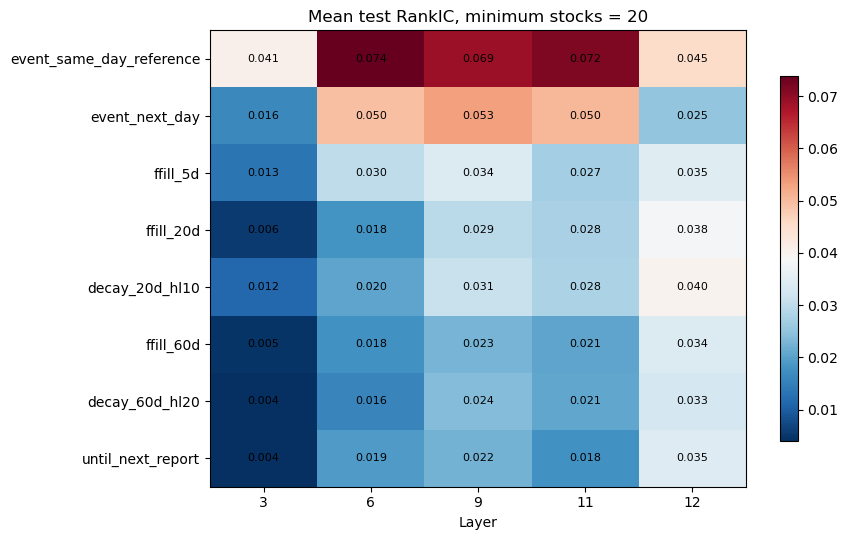

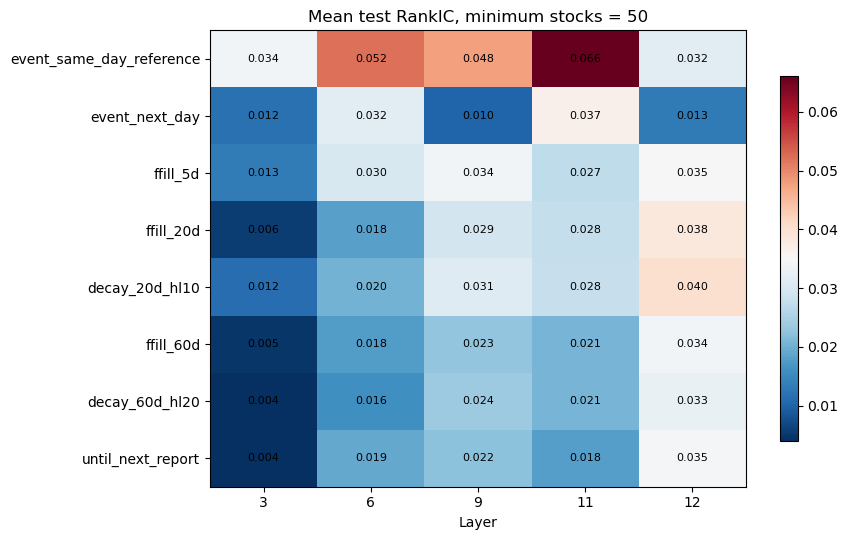

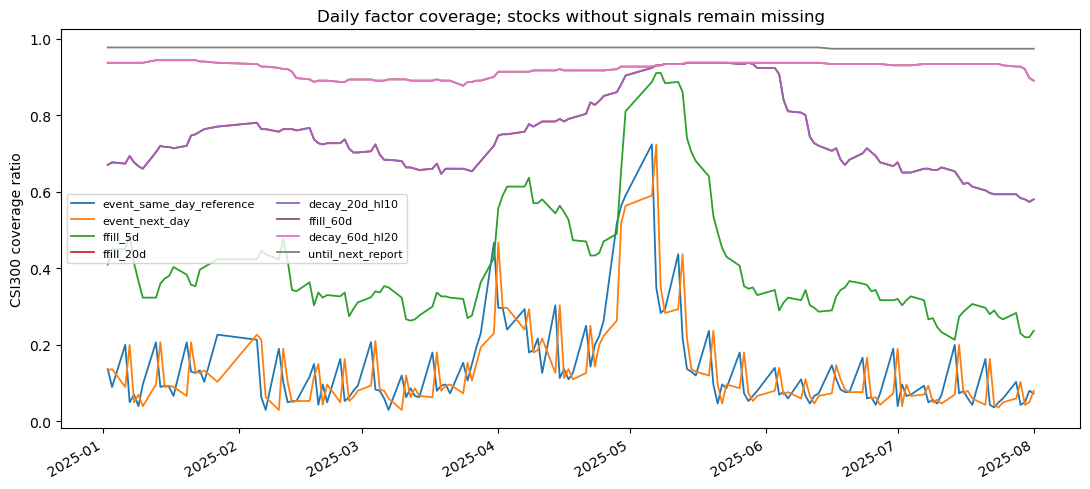

,method,layer,age_bucket,mean_rank_ic,n_days,mean_n_stocks
0,decay_20d_hl10,3,0,0.016372,107,40.858156
1,decay_20d_hl10,3,1-4,0.013856,141,79.865248
2,decay_20d_hl10,3,10-19,-0.014142,126,51.438849
3,decay_20d_hl10,3,5-9,0.002810,129,51.411348
4,decay_20d_hl10,6,0,0.049524,107,40.858156
...,...,...,...,...,...,...
135,until_next_report,12,1-4,0.035051,141,79.865248
136,until_next_report,12,10-19,0.054569,126,51.438849
137,until_next_report,12,20-59,-0.001565,117,59.346457
138,until_next_report,12,5-9,0.035940,129,51.411348


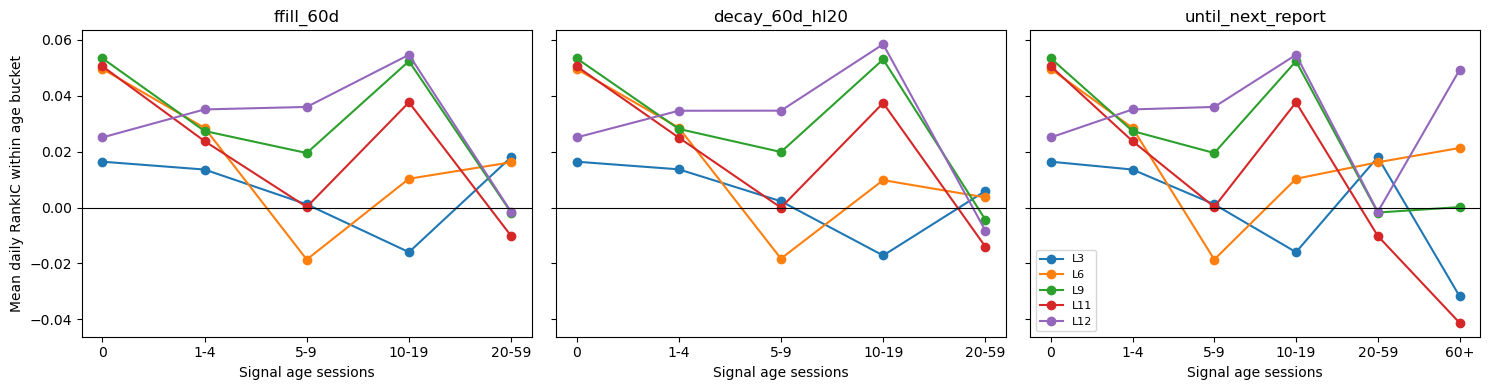

In [11]:
def heatmap_figure(frame, threshold):
    selected = frame[frame['minimum_observations'].eq(threshold)].copy()
    matrix = selected.pivot(index='method', columns='layer', values='mean_rank_ic').reindex(METHOD_ORDER).reindex(columns=LAYERS)
    figure, axis = plt.subplots(figsize=(9, 5.5))
    image = axis.imshow(matrix.to_numpy(dtype=float), cmap='RdBu_r', aspect='auto')
    axis.set_xticks(range(len(matrix.columns)), labels=matrix.columns)
    axis.set_yticks(range(len(matrix.index)), labels=matrix.index)
    axis.set_xlabel('Layer')
    axis.set_title(f'Mean test RankIC, minimum stocks = {threshold}')
    for row in range(matrix.shape[0]):
        for column in range(matrix.shape[1]):
            value = matrix.iloc[row, column]
            if np.isfinite(value):
                axis.text(column, row, f'{value:.3f}', ha='center', va='center', fontsize=8)
    figure.colorbar(image, ax=axis, shrink=0.8)
    figure.tight_layout()
    plt.close(figure)
    return figure


def coverage_figure(frame):
    selected = frame[frame['layer'].eq(LAYERS[0])].copy()
    figure, axis = plt.subplots(figsize=(11, 5))
    for method in METHOD_ORDER:
        values = selected[selected['method'].eq(method)].sort_values('trading_date')
        axis.plot(values['trading_date'], values['coverage_ratio'], label=method, linewidth=1.3)
    axis.set_ylabel('CSI300 coverage ratio')
    axis.set_title('Daily factor coverage; stocks without signals remain missing')
    axis.legend(ncol=2, fontsize=8)
    figure.autofmt_xdate()
    figure.tight_layout()
    plt.close(figure)
    return figure


def age_rank_ic_figure(frame):
    selected = frame[frame['method'].isin(['ffill_60d', 'decay_60d_hl20', 'until_next_report'])].copy()
    labels = ['0', '1-4', '5-9', '10-19', '20-59', '60+']
    figure, axes = plt.subplots(1, 3, figsize=(15, 4), sharey=True)
    for axis, method in zip(axes, ['ffill_60d', 'decay_60d_hl20', 'until_next_report']):
        method_frame = selected[selected['method'].eq(method)]
        for layer in LAYERS:
            values = method_frame[method_frame['layer'].eq(layer)].set_index('age_bucket').reindex(labels)
            axis.plot(labels, values['mean_rank_ic'], marker='o', label=f'L{layer}')
        axis.axhline(0.0, color='black', linewidth=0.8)
        axis.set_title(method)
        axis.set_xlabel('Signal age sessions')
    axes[0].set_ylabel('Mean daily RankIC within age bucket')
    axes[-1].legend(fontsize=8)
    figure.tight_layout()
    plt.close(figure)
    return figure

display(rank_ic_summary.sort_values(['minimum_observations', 'method', 'layer']))
for threshold in MINIMUM_OBSERVATIONS:
    display(heatmap_figure(rank_ic_summary, threshold))
display(coverage_figure(daily_coverage))
display(age_summary.sort_values(['method', 'layer', 'age_bucket']))
display(age_rank_ic_figure(age_summary))

In [12]:
display(pd.Series({
    'run_directory': str(OUTPUT_DIR),
    'task_id': TASK_ID,
    'layers': str(LAYERS),
    'methods': len(METHOD_ORDER),
    'test_is_opened': True,
    'interpretation': 'exploratory_only',
    'status': 'completed',
}, name='run_summary'))

run_directory     /home/intern_fjq_2026/Projects/chinese-wwm-rob...
task_id                                    residual_signed_raw__fh0
layers                                            (3, 6, 9, 11, 12)
methods                                                           8
test_is_opened                                                 True
interpretation                                     exploratory_only
status                                                    completed
Name: run_summary, dtype: object

In [53]:
# ic = rank_ic_summary.sort_values(['minimum_observations', 'method', 'layer'])

In [54]:
# ic[(ic["layer"] == 12) & (ic["mean_coverage_ratio"] > 0.7)]

In [55]:
# ic[ic["method"] == "ffill_60d"]

In [56]:
# ic70 = ic[ic["mean_coverage_ratio"]>0.7]

In [57]:
# max_idx = ic70["mean_rank_ic"].idxmax()
# ic.loc[max_idx]